Cell 1 — Setup and check GPU:

In [3]:
import torch
import torch.nn as nn
import numpy as np
import joblib
import gc
import os
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import classification_report, roc_auc_score

FEAT_DIR   = 'D:/DDI Project/data/features/'
MODEL_PATH = 'D:/DDI Project/model_nn.pt'

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device      : {device}")

if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("WARNING: GPU not found. Training will run on CPU and will be slow.")

print("Cell 1 done")

Device      : cuda
GPU         : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM        : 6.0 GB
CUDA version: 12.1
Cell 1 done


Cell 2 — Load features and prepare balanced samples:

In [4]:
# Load feature files via memory map — stays on disk
X = np.load(FEAT_DIR + 'X.npy', mmap_mode='r')
y = np.load(FEAT_DIR + 'y.npy', mmap_mode='r')

# Load the saved split indices from 03_train_classical
idx_tr = np.load(FEAT_DIR + 'idx_train.npy')
idx_vl = np.load(FEAT_DIR + 'idx_val.npy')
idx_te = np.load(FEAT_DIR + 'idx_test.npy')

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Train   : {len(idx_tr):,}")
print(f"Val     : {len(idx_vl):,}")
print(f"Test    : {len(idx_te):,}")

# Balanced sample — capped to available counts
PER_CLASS = 50_000

rng    = np.random.default_rng(42)
pos_tr = idx_tr[y[idx_tr] == 1]
neg_tr = idx_tr[y[idx_tr] == 0]
pos_vl = idx_vl[y[idx_vl] == 1]
neg_vl = idx_vl[y[idx_vl] == 0]

# Cap to the smaller class so replace=False never fails
per_class_tr = min(PER_CLASS, len(pos_tr), len(neg_tr))
per_class_vl = min(10_000, len(pos_vl), len(neg_vl))

print(f"\nClass counts  — train pos={len(pos_tr):,}  neg={len(neg_tr):,}")
print(f"Class counts  — val   pos={len(pos_vl):,}  neg={len(neg_vl):,}")
print(f"Sampling      — train {per_class_tr:,}/class, val {per_class_vl:,}/class")

sample_tr = np.concatenate([
    rng.choice(pos_tr, size=per_class_tr, replace=False),
    rng.choice(neg_tr, size=per_class_tr, replace=False)
])
sample_vl = np.concatenate([
    rng.choice(pos_vl, size=per_class_vl, replace=False),
    rng.choice(neg_vl, size=per_class_vl, replace=False)
])


# Load into RAM as float32
X_tr = np.array(X[sample_tr], dtype=np.float32)
y_tr = np.array(y[sample_tr], dtype=np.float32)
X_vl = np.array(X[sample_vl], dtype=np.float32)
y_vl = np.array(y[sample_vl], dtype=np.float32)

print(f"\nTraining sample   : {X_tr.shape}")
print(f"Validation sample : {X_vl.shape}")
print(f"RAM used          : ~{(X_tr.nbytes + X_vl.nbytes)/1024**3:.2f} GB")
print(f"Pos/Neg train     : {int(y_tr.sum())} / {int((y_tr==0).sum())}")
print("Cell 2 done")

X shape : (133063, 8193)
y shape : (133063,)
Train   : 93,144
Val     : 13,173
Test    : 26,746

Class counts  — train pos=46,511  neg=46,633
Class counts  — val   pos=6,578  neg=6,595
Sampling      — train 46,511/class, val 6,578/class

Training sample   : (93022, 8193)
Validation sample : (13156, 8193)
RAM used          : ~3.24 GB
Pos/Neg train     : 46511 / 46511
Cell 2 done


Cell 3 — Build PyTorch Dataset and DataLoaders:

In [5]:
class DDIDataset(Dataset):
    """
    Simple PyTorch dataset wrapper.
    Takes numpy arrays and returns torch tensors one sample at a time.
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 2048   # large batch — GPU handles this easily

train_ds = DDIDataset(X_tr, y_tr)
val_ds   = DDIDataset(X_vl, y_vl)

train_loader = DataLoader(
    train_ds,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 0    # set to 0 on Windows to avoid multiprocessing issues
)
val_loader = DataLoader(
    val_ds,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0
)

print(f"Batch size       : {BATCH_SIZE}")
print(f"Training batches : {len(train_loader)}")
print(f"Val batches      : {len(val_loader)}")
print("Cell 3 done")

Batch size       : 2048
Training batches : 46
Val batches      : 7
Cell 3 done


Cell 4 — Define the neural network:

In [6]:
class DDINet(nn.Module):
    """
    Feedforward neural network for binary DDI classification.

    Architecture:
      Input (8193) → 1024 → 512 → 128 → 1 (sigmoid)

    BatchNorm after each hidden layer stabilises training.
    Dropout prevents overfitting on the smaller dataset.
    """
    def __init__(self, input_dim=8193):
        super().__init__()

        self.net = nn.Sequential(

            # Layer 1 — reduce from 8193 to 1024
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 2 — reduce to 512
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 3 — reduce to 128
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Output — single value, sigmoid squishes to 0-1
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


# Build and send to GPU
model = DDINet(input_dim=8193).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model architecture:")
print(model)
print(f"\nTotal parameters : {total_params:,}")
print(f"Running on       : {device}")
print("Cell 4 done")

Model architecture:
DDINet(
  (net): Sequential(
    (0): Linear(in_features=8193, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=512, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=128, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

Total parameters : 8,984,577
Running on       : cuda
Cell 4 done


Cell 5 — Train the network:

In [7]:
EPOCHS   = 30
LR       = 0.001

optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(
    optimizer, mode='min', patience=3,
    factor=0.5, verbose=True
)
criterion = nn.BCELoss()

best_val_loss = float('inf')
train_losses  = []
val_losses    = []

print(f"Starting training for {EPOCHS} epochs...")
print(f"Batch size : {BATCH_SIZE}")
print(f"Optimizer  : Adam (lr={LR})")
print("-" * 60)

for epoch in range(EPOCHS):

    # ── Training phase ────────────────────────────────────────
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        output = model(X_batch)
        loss   = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── Validation phase ──────────────────────────────────────
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            output  = model(X_batch)
            loss    = criterion(output, y_batch)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Step the learning rate scheduler
    scheduler.step(avg_val_loss)

    # Save if this is the best validation loss so far
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), MODEL_PATH)
        saved = " ← best saved"
    else:
        saved = ""

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f}{saved}")

print("-" * 60)
print(f"Training complete. Best val loss: {best_val_loss:.4f}")
print(f"Model saved to: {MODEL_PATH}")

d:\DDI Project\ddienv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Starting training for 30 epochs...
Batch size : 2048
Optimizer  : Adam (lr=0.001)
------------------------------------------------------------
Epoch 01/30 | Train Loss: 0.6427 | Val Loss: 0.6071 ← best saved
Epoch 02/30 | Train Loss: 0.5840 | Val Loss: 0.5918 ← best saved
Epoch 03/30 | Train Loss: 0.5553 | Val Loss: 0.5935
Epoch 04/30 | Train Loss: 0.5320 | Val Loss: 0.5862 ← best saved
Epoch 05/30 | Train Loss: 0.5067 | Val Loss: 0.5908
Epoch 06/30 | Train Loss: 0.4851 | Val Loss: 0.6069
Epoch 07/30 | Train Loss: 0.4647 | Val Loss: 0.6252
Epoch 08/30 | Train Loss: 0.4393 | Val Loss: 0.6223
Epoch 09/30 | Train Loss: 0.3797 | Val Loss: 0.6777
Epoch 10/30 | Train Loss: 0.3478 | Val Loss: 0.7395
Epoch 11/30 | Train Loss: 0.3249 | Val Loss: 0.7591
Epoch 12/30 | Train Loss: 0.3074 | Val Loss: 0.7824
Epoch 13/30 | Train Loss: 0.2633 | Val Loss: 0.8204
Epoch 14/30 | Train Loss: 0.2403 | Val Loss: 0.8769
Epoch 15/30 | Train Loss: 0.2297 | Val Loss: 0.9315
Epoch 16/30 | Train Loss: 0.2165 | Val

Cell 6 — Plot training curves:

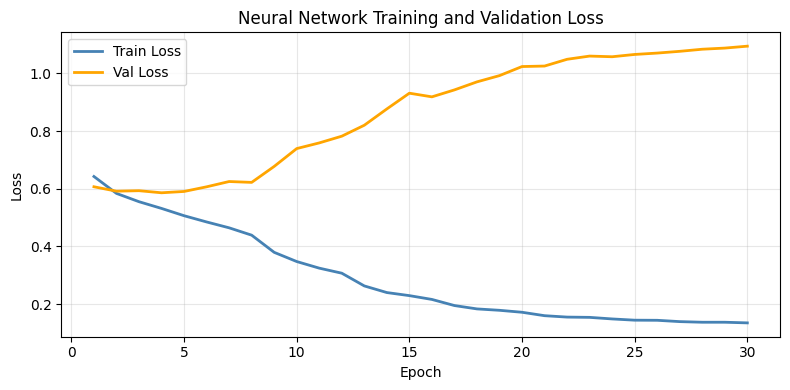

Saved: plots/nn_loss_curve.png


In [8]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 1, figsize=(8, 4))

axes.plot(epochs_range, train_losses, label='Train Loss', color='steelblue', lw=2)
axes.plot(epochs_range, val_losses,   label='Val Loss',   color='orange',    lw=2)
axes.set_xlabel('Epoch')
axes.set_ylabel('Loss')
axes.set_title('Neural Network Training and Validation Loss')
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('D:/DDI Project/plots/nn_loss_curve.png', dpi=150)
plt.show()
print("Saved: plots/nn_loss_curve.png")

Cell 7 — Evaluate on validation set:

In [9]:
# Load the best saved checkpoint
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

all_probs = []
all_preds = []
all_true  = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        probs   = model(X_batch).cpu().numpy()
        preds   = (probs >= 0.5).astype(int)

        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_true.extend(y_batch.numpy().astype(int).tolist())

print("--- Neural Network (Validation) ---")
print(classification_report(all_true, all_preds))
print(f"AUROC: {roc_auc_score(all_true, all_probs):.4f}")

C:\Users\sharm\AppData\Local\Temp\ipykernel_3688\1781883755.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=dev

--- Neural Network (Validation) ---
              precision    recall  f1-score   support

           0       0.69      0.68      0.68      6578
           1       0.68      0.69      0.69      6578

    accuracy                           0.69     13156
   macro avg       0.69      0.69      0.69     13156
weighted avg       0.69      0.69      0.69     13156

AUROC: 0.7563


Cell 8 — Compare neural network vs classical models:

In [10]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def get_metrics(name, y_true, y_pred, y_prob):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred),  4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall'   : round(recall_score(y_true, y_pred),    4),
        'F1'       : round(f1_score(y_true, y_pred),        4),
        'AUROC'    : round(roc_auc_score(y_true, y_prob),   4),
    }

results = pd.DataFrame([
    get_metrics('Neural Network', all_true, all_preds, all_probs),
])

print("--- Neural Network Summary ---")
print(results.to_string(index=False))
print()
print("Compare this against the classical models from 03_train_classical.ipynb")
print("Next: run 05_evaluate.ipynb for final test set evaluation")

--- Neural Network Summary ---
         Model  Accuracy  Precision  Recall     F1  AUROC
Neural Network    0.6853     0.6838  0.6896 0.6866 0.7563

Compare this against the classical models from 03_train_classical.ipynb
Next: run 05_evaluate.ipynb for final test set evaluation


Cell 9 — Free GPU memory:

In [11]:
# Move model off GPU and free VRAM
model.cpu()
del model, train_ds, val_ds, train_loader, val_loader
del X_tr, y_tr, X_vl, y_vl
gc.collect()
torch.cuda.empty_cache()

if torch.cuda.is_available():
    used  = torch.cuda.memory_allocated() / 1024**2
    total = torch.cuda.get_device_properties(0).total_memory / 1024**2
    print(f"GPU VRAM used after cleanup: {used:.0f} MB / {total:.0f} MB")

print("GPU memory freed")
print("model_nn.pt saved and ready for 05_evaluate.ipynb")

GPU VRAM used after cleanup: 112 MB / 6140 MB
GPU memory freed
model_nn.pt saved and ready for 05_evaluate.ipynb
